# Tomato quality: Classifying tomato images with CNNs

This notebook trains a small network, `solanum_grader`, to look at one photo and call the tomato Damaged, Old, Ripe, or Unripe.

Damaged fruit is the one a packing line has to catch, and it is also the smallest class in the set. A single accuracy number can look strong while that class is still being missed, because the other three classes are much larger. Alongside accuracy we read the macro F1. It gives each class the same vote, so Damaged counts as much as Ripe.

## Split

The photos come from the Kaggle set [enalis/tomatoes-dataset](https://www.kaggle.com/datasets/enalis/tomatoes-dataset), folder `content/ieee-mbl-cls`.

The original `train/` folder is divided 85/15. The split is stratified, so each class keeps its share in both parts, and the seed is 42, so the same division can be repeated. The larger part is what the network learns from. The smaller part is the validation set: while training, EarlyStopping and the learning-rate schedule look only at these photos. The original `val/` folder is saved for the end. It is the test set, and it is scored once, after the weights have been chosen.

| Split | Images | Damaged | Old | Ripe | Unripe |
|---|---:|---:|---:|---:|---:|
| Train | 5525 | 807 | 1693 | 1678 | 1347 |
| Val | 976 | 142 | 299 | 297 | 238 |
| Test | 725 | 106 | 222 | 220 | 177 |

Class names follow alphabetical order, which is what `sorted()` returns: Damaged, Old, Ripe, Unripe. Every image is resized to 256×256, and its pixels are divided by 255 so each color channel lies between 0 and 1.

In [ ]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Shared by the stratified split and by TensorFlow, so this shuffle can be repeated.
SEED = 42
tf.random.set_seed(SEED)

In [ ]:
BASE_PATH_KAGGLE = '/kaggle/input/datasets/enalis/tomatoes-dataset/content/ieee-mbl-cls'
# On Kaggle the path above is the dataset mount. Elsewhere, point TOMATO_DATA_ROOT at the ieee-mbl-cls folder.
BASE_PATH = os.environ.get('TOMATO_DATA_ROOT', BASE_PATH_KAGGLE)
TRAIN_PATH = os.path.join(BASE_PATH, 'train')
VAL_PATH   = os.path.join(BASE_PATH, 'val')

IMG_SIZE   = (256, 256)
BATCH_SIZE = 32
VAL_SPLIT  = 0.15

# Every file under train/, with its class index
class_names = sorted(os.listdir(TRAIN_PATH))   # ['Damaged','Old','Ripe','Unripe']
filepaths, labels = [], []

for idx, cls in enumerate(class_names):
    cls_dir = os.path.join(TRAIN_PATH, cls)
    for fname in os.listdir(cls_dir):
        filepaths.append(os.path.join(cls_dir, fname))
        labels.append(idx)

filepaths = np.array(filepaths)
labels    = np.array(labels)

# Stratified split
train_paths, val_paths, train_labels, val_labels = train_test_split(
    filepaths, labels,
    test_size=VAL_SPLIT,
    stratify=labels,
    random_state=SEED,
    shuffle=True
)

# Class counts for this split
print("Train distribution:", np.bincount(train_labels, minlength=len(class_names)))
print("Val distribution  :", np.bincount(val_labels,   minlength=len(class_names)))

# Decode one image from its path
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0    # scale pixels to [0, 1]
    return img, label

# Build the datasets
def make_ds(paths, labels, shuffle):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=SEED)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(train_paths, train_labels, shuffle=True)
val_ds   = make_ds(val_paths,   val_labels,   shuffle=False)

# Test is the original val/ folder, through the same pipeline
test_paths, test_labels = [], []
for idx, cls in enumerate(class_names):
    cls_dir = os.path.join(VAL_PATH, cls)
    for fname in os.listdir(cls_dir):
        test_paths.append(os.path.join(cls_dir, fname))
        test_labels.append(idx)

test_paths  = np.array(test_paths)
test_labels = np.array(test_labels)

test_ds = make_ds(test_paths, test_labels, shuffle=False)

NUM_CLASES = len(class_names)
print("Classes:", class_names)
print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

Train distribution: [ 807 1693 1678 1347]
Val distribution  : [142 299 297 238]


I0000 00:00:1790843485.784072      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790843485.788827      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Classes: ['Damaged', 'Old', 'Ripe', 'Unripe']
Train: 5525 | Val: 976 | Test: 725


## Model

`solanum_grader` is a residual CNN. In a residual block the layer adds its input back onto its output, so the block can learn a small correction instead of drawing the image again from scratch.

The shape is straightforward. A stem of 32 filters opens the network. Three stages follow, at 64, 128, and 256 filters, with two residual blocks in each stage. Batch normalization sits after the convolutions and keeps the activations on a steady scale. After each pooling step, spatial dropout blanks out some feature maps during training, which pushes the network to use more than one pattern. At the end, global average pooling turns every map into a single number, and a softmax turns those numbers into four probabilities, one per class.

Three more layers sit at the front: a horizontal flip, a small rotation of 0.1, and a small zoom of 0.1. During training they vary each batch, so the network sees more than the original photos. They belong to the model. When a photo is scored, the call uses `training=False`, and those layers pass the image through unchanged.


In [ ]:
# Augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="augmentation")

In [ ]:
inputs = keras.Input(shape=(256, 256, 3), name='input')
x = data_augmentation(inputs)

# ---------------- Stem: 256x256x32 ----------------
x = layers.Conv2D(32, 3, padding='same', use_bias=False, name='stem_conv')(x)
x = layers.BatchNormalization(name='stem_bn')(x)
x = layers.Activation('relu', name='stem_act')(x)

# ---------------- Stage 1: 256x256x64 ----------------
# Block 1
s1a_shortcut = x
s1a = layers.Conv2D(64, 3, padding='same', use_bias=False, name='s1a_conv1')(x)
s1a = layers.BatchNormalization(name='s1a_bn1')(s1a)
s1a = layers.Activation('relu', name='s1a_act1')(s1a)
s1a = layers.Conv2D(64, 3, padding='same', use_bias=False, name='s1a_conv2')(s1a)
s1a = layers.BatchNormalization(name='s1a_bn2')(s1a)
s1a_shortcut = layers.Conv2D(64, 1, padding='same', use_bias=False,
                             name='s1a_sc_conv')(s1a_shortcut)
s1a_shortcut = layers.BatchNormalization(name='s1a_sc_bn')(s1a_shortcut)
x = layers.Add(name='s1a_add')([s1a, s1a_shortcut])
x = layers.Activation('relu', name='s1a_out')(x)

# Block 2
s1b = layers.Conv2D(64, 3, padding='same', use_bias=False, name='s1b_conv1')(x)
s1b = layers.BatchNormalization(name='s1b_bn1')(s1b)
s1b = layers.Activation('relu', name='s1b_act1')(s1b)
s1b = layers.Conv2D(64, 3, padding='same', use_bias=False, name='s1b_conv2')(s1b)
s1b = layers.BatchNormalization(name='s1b_bn2')(s1b)
x = layers.Add(name='s1b_add')([s1b, x])
x = layers.Activation('relu', name='s1b_out')(x)

x = layers.MaxPooling2D(2, name='pool_1')(x)          # 128x128x64
x = layers.SpatialDropout2D(0.10, name='sdrop_1')(x)

# ---------------- Stage 2: 128x128x128 ----------------
# Block 3 
s2a_shortcut = x
s2a = layers.Conv2D(128, 3, padding='same', use_bias=False, name='s2a_conv1')(x)
s2a = layers.BatchNormalization(name='s2a_bn1')(s2a)
s2a = layers.Activation('relu', name='s2a_act1')(s2a)
s2a = layers.Conv2D(128, 3, padding='same', use_bias=False, name='s2a_conv2')(s2a)
s2a = layers.BatchNormalization(name='s2a_bn2')(s2a)
s2a_shortcut = layers.Conv2D(128, 1, padding='same', use_bias=False,
                             name='s2a_sc_conv')(s2a_shortcut)
s2a_shortcut = layers.BatchNormalization(name='s2a_sc_bn')(s2a_shortcut)
x = layers.Add(name='s2a_add')([s2a, s2a_shortcut])
x = layers.Activation('relu', name='s2a_out')(x)

# Block 4
s2b = layers.Conv2D(128, 3, padding='same', use_bias=False, name='s2b_conv1')(x)
s2b = layers.BatchNormalization(name='s2b_bn1')(s2b)
s2b = layers.Activation('relu', name='s2b_act1')(s2b)
s2b = layers.Conv2D(128, 3, padding='same', use_bias=False, name='s2b_conv2')(s2b)
s2b = layers.BatchNormalization(name='s2b_bn2')(s2b)
x = layers.Add(name='s2b_add')([s2b, x])
x = layers.Activation('relu', name='s2b_out')(x)

x = layers.MaxPooling2D(2, name='pool_2')(x)          # 64x64x128
x = layers.SpatialDropout2D(0.15, name='sdrop_2')(x)

# ---------------- Stage 3: 64x64x256 ----------------
# Block 5 
s3a_shortcut = x
s3a = layers.Conv2D(256, 3, padding='same', use_bias=False, name='s3a_conv1')(x)
s3a = layers.BatchNormalization(name='s3a_bn1')(s3a)
s3a = layers.Activation('relu', name='s3a_act1')(s3a)
s3a = layers.Conv2D(256, 3, padding='same', use_bias=False, name='s3a_conv2')(s3a)
s3a = layers.BatchNormalization(name='s3a_bn2')(s3a)
s3a_shortcut = layers.Conv2D(256, 1, padding='same', use_bias=False,
                             name='s3a_sc_conv')(s3a_shortcut)
s3a_shortcut = layers.BatchNormalization(name='s3a_sc_bn')(s3a_shortcut)
x = layers.Add(name='s3a_add')([s3a, s3a_shortcut])
x = layers.Activation('relu', name='s3a_out')(x)

# Block 6
s3b = layers.Conv2D(256, 3, padding='same', use_bias=False, name='s3b_conv1')(x)
s3b = layers.BatchNormalization(name='s3b_bn1')(s3b)
s3b = layers.Activation('relu', name='s3b_act1')(s3b)
s3b = layers.Conv2D(256, 3, padding='same', use_bias=False, name='s3b_conv2')(s3b)
s3b = layers.BatchNormalization(name='s3b_bn2')(s3b)
x = layers.Add(name='s3b_add')([s3b, x])
x = layers.Activation('relu', name='s3b_out')(x)

x = layers.MaxPooling2D(2, name='pool_3')(x)          # 32x32x256
x = layers.SpatialDropout2D(0.20, name='sdrop_3')(x)

# ---------------- Head ----------------
x = layers.GlobalAveragePooling2D(name='gap')(x)      # 256 features
x = layers.Dropout(0.3, name='drop_final')(x)
outputs = layers.Dense(NUM_CLASES, activation='softmax', name='output')(x)

model = keras.Model(inputs=inputs, outputs=outputs, name='solanum_grader')
model.summary()

Model: "solanum_grader"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 256, 256,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 256, 256,  │          0 │ input[0][0]       │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 256, 256,  │        864 │ augmentation[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 256, 256,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_act            │ (None, 256, 256,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1a_conv1 (Conv2D)  │ (None, 256, 256,  │     18,432 │ stem_act[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1a_bn1             │ (None, 256, 256,  │        256 │ s1a_conv1[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1a_act1            │ (None, 256, 256,  │          0 │ s1a_bn1[0][0]     │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1a_conv2 (Conv2D)  │ (None, 256, 256,  │     36,864 │ s1a_act1[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1a_sc_conv         │ (None, 256, 256,  │      2,048 │ stem_act[0][0]    │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1a_bn2             │ (None, 256, 256,  │        256 │ s1a_conv2[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1a_sc_bn           │ (None, 256, 256,  │        256 │ s1a_sc_conv[0][0] │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1a_add (Add)       │ (None, 256, 256,  │          0 │ s1a_bn2[0][0],    │
│                     │ 64)               │            │ s1a_sc_bn[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1a_out             │ (None, 256, 256,  │          0 │ s1a_add[0][0]     │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1b_conv1 (Conv2D)  │ (None, 256, 256,  │     36,864 │ s1a_out[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1b_bn1             │ (None, 256, 256,  │        256 │ s1b_conv1[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1b_act1            │ (None, 256, 256,  │          0 │ s1b_bn1[0][0]   

 Total params: 2,763,492 (10.54 MB)

 Trainable params: 2,758,948 (10.52 MB)

 Non-trainable params: 4,544 (17.75 KB)

In [ ]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    train_ds,
    epochs=80,
    validation_data=val_ds,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/80


E0000 00:00:1790843497.695640      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/solanum_grader_1/sdrop_1_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


173/173 ━━━━━━━━━━━━━━━━━━━━ 408s 2s/step - accuracy: 0.7068 - loss: 0.8064 - val_accuracy: 0.3053 - val_loss: 3.0263 - learning_rate: 0.0010
Epoch 2/80
173/173 ━━━━━━━━━━━━━━━━━━━━ 364s 2s/step - accuracy: 0.7788 - loss: 0.5696 - val_accuracy: 0.3945 - val_loss: 2.0052 - learning_rate: 0.0010
Epoch 3/80
173/173 ━━━━━━━━━━━━━━━━━━━━ 365s 2s/step - accuracy: 0.8011 - loss: 0.5182 - val_accuracy: 0.5645 - val_loss: 1.3806 - learning_rate: 0.0010
Epoch 4/80
173/173 ━━━━━━━━━━━━━━━━━━━━ 364s 2s/step - accuracy: 0.8094 - loss: 0.4897 - val_accuracy: 0.8268 - val_loss: 0.4387 - learning_rate: 0.0010
Epoch 5/80
173/173 ━━━━━━━━━━━━━━━━━━━━ 364s 2s/step - accuracy: 0.8199 - loss: 0.4652 - val_accuracy: 0.6609 - val_loss: 0.9309 - learning_rate: 0.0010
Epoch 6/80
173/173 ━━━━━━━━━━━━━━━━━━━━ 364s 2s/step - accuracy: 0.8177 - loss: 0.4618 - val_accuracy: 0.8043 - val_loss: 0.5130 - learning_rate: 0.0010
Epoch 7/80
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8358 - loss: 0.4351
Epoch 7:

## Evaluation

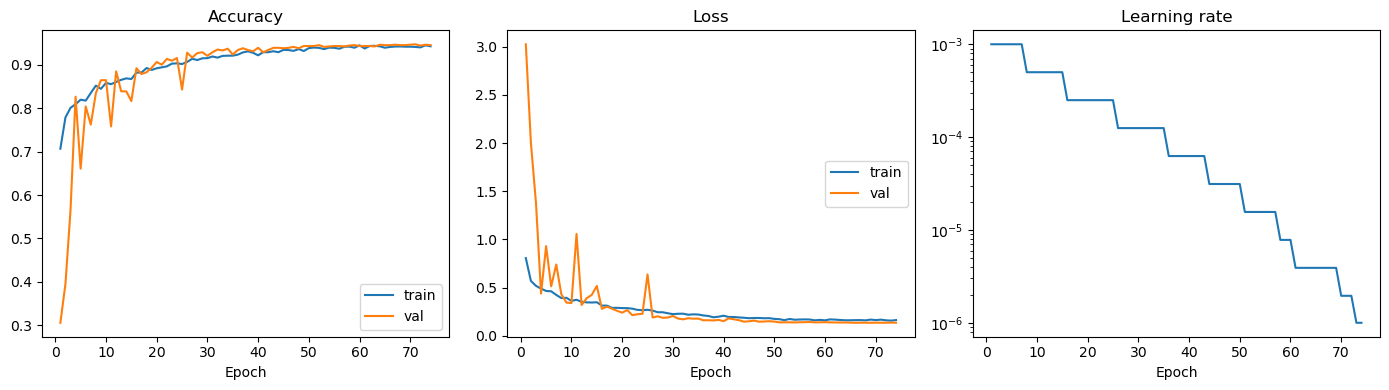

In [ ]:
# Curves for the finished run, read from reports/metrics.csv.
import csv
from pathlib import Path

candidatos = [Path("../reports/metrics.csv"), Path("reports/metrics.csv")]
csv_path = next((p for p in candidatos if p.is_file()), None)
if csv_path is None:
    print(
        "This cell redraws the curves from reports/metrics.csv. "
        "Place that file next to the notebook, or one directory above it, and run the cell again."
    )
else:
    epochs, acc, loss, val_acc, val_loss, lrs = [], [], [], [], [], []
    with csv_path.open(newline="") as f:
        for row in csv.DictReader(f):
            epochs.append(int(row["epoch"]))
            acc.append(float(row["accuracy"]))
            loss.append(float(row["loss"]))
            val_acc.append(float(row["val_accuracy"]))
            val_loss.append(float(row["val_loss"]))
            lrs.append(float(row["learning_rate"]))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].plot(epochs, acc, label="train")
    axes[0].plot(epochs, val_acc, label="val")
    axes[0].set_title("Accuracy")
    axes[0].legend(loc="lower right")
    axes[1].plot(epochs, loss, label="train")
    axes[1].plot(epochs, val_loss, label="val")
    axes[1].set_title("Loss")
    axes[1].legend(loc="center right")
    axes[2].plot(epochs, lrs)
    axes[2].set_title("Learning rate")
    axes[2].set_yscale("log")
    for ax in axes:
        ax.set_xlabel("Epoch")
    fig.tight_layout()
    plt.show()

Test accuracy: 0.9379
              precision    recall  f1-score   support

     Damaged       0.95      0.71      0.81       106
         Old       0.88      0.96      0.92       222
        Ripe       0.97      0.98      0.98       220
      Unripe       0.97      0.99      0.98       177

    accuracy                           0.94       725
   macro avg       0.94      0.91      0.92       725
weighted avg       0.94      0.94      0.94       725



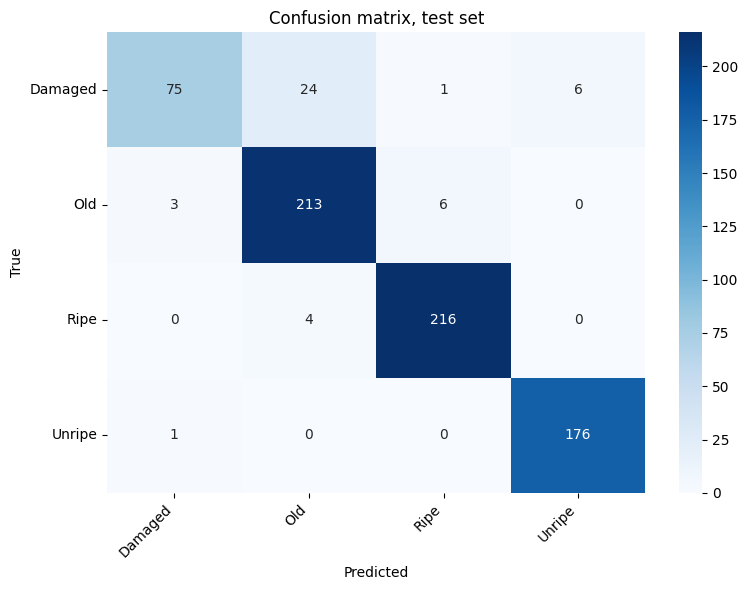

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

loss, acc = model.evaluate(test_ds, verbose=0)
print(f"Test accuracy: {acc:.4f}")

y_pred_probs = []
y_true = []

for x_batch, y_batch in test_ds:                  # ← test_ds
    y_pred_probs.append(model.predict(x_batch, verbose=0))
    y_true.append(y_batch.numpy())

y_pred_probs = np.concatenate(y_pred_probs, axis=0)
y_true       = np.concatenate(y_true, axis=0)
y_pred       = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion matrix, test set')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

The fit was allowed 80 epochs of Adam, starting at a learning rate of 0.001. Two rules watched the validation loss. After 8 epochs without an improvement, training stops and the weights from the best epoch are restored. After 3 epochs without an improvement, the learning rate is cut in half, down to a floor of 0.000001.

Accuracy rises quickly and then levels off near 0.94. The validation curve swings in the first epochs, while the network is still unsure, and later settles beside the training curve. Loss tells the same story from the other side: validation loss opens near 3, spikes a few times early on, and then falls in line with the training loss. The learning-rate panel is a staircase. Each step down is the scheduler taking a smaller step once progress stalls.

Training stopped at epoch 74. The lowest validation loss was 0.1347, at epoch 66, with a validation accuracy of 0.9457. Those are the weights used for the test below. On a T4, an epoch took about six minutes.

The cell above scores the 725 test photos with the weights from epoch 66. This folder was held out while the stopping rule and the learning rate were being decided.

| Class | Precision | Recall | F1 | Support |
|---|---:|---:|---:|---:|
| Damaged | 0.95 | 0.71 | 0.81 | 106 |
| Old | 0.88 | 0.96 | 0.92 | 222 |
| Ripe | 0.97 | 0.98 | 0.98 | 220 |
| Unripe | 0.97 | 0.99 | 0.98 | 177 |

Accuracy is 0.9379. The macro average, with one vote per class, is 0.94 precision, 0.91 recall, and 0.92 F1. The weighted average, which follows how many photos each class has, is 0.94.

Ripe and Unripe are nearly settled, and Old is close behind them. Damaged is the class that still gives ground: precision 0.95, recall 0.71, F1 0.81.
If we look at the confusion matri, of the 106 Damaged tomatoes, 75 sit on that diagonal. The other 31 are misses. The fruit was damaged, and the model gave it another name: 24 are called Old, 6 Unripe, and 1 Ripe. An old tomato and a damaged one can look alike, which is why most of this confusion sits between those two columns.


Precision of 0.95 is the other side of the same count. When the model says Damaged, it is usually right. The open question is the damaged fruit it lets pass.


In [ ]:
os.makedirs("models", exist_ok=True)
model.save("models/solanum_grader.keras")
print("Saved to models/solanum_grader.keras")

Saved to models/solanum_grader.keras
